### Imports

In [ ]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

### Load Data

In [22]:
from src.data.load_data import load_tables

accidents, weather, raw = load_tables()

C:\Users\Luisa\Documents\maestria\aprendizaje_automatico\urban-accident-risk-prediction
C:\Users\Luisa\Documents\maestria\aprendizaje_automatico\urban-accident-risk-prediction\data\raw\data_accidentes.sqlite3
True


### Information

In [3]:
print("Accidents:")
print(accidents.head())
print("\n",accidents.shape)
print("\n", accidents.info())

Accidents:
                   TW             BARRIO       Lat        Lon    Dia_sem  Mes  \
0 2017-07-20 08:00:00           sandiego  6.233985 -75.570146     JUEVES    7   
1 2017-06-15 16:00:00         lasacacias  6.238844 -75.600280     JUEVES    6   
2 2017-07-02 16:00:00        lopezdemesa  6.285074 -75.584306    DOMINGO    7   
3 2017-03-29 18:00:00  losconquistadores  6.239497 -75.583062  MIERCOLES    3   
4 2017-07-26 20:00:00      cuartabrigada  6.260463 -75.590193  MIERCOLES    7   

   Dia  Hora  
0   20     8  
1   15    16  
2    2    16  
3   29    18  
4   26    20  

 (120587, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120587 entries, 0 to 120586
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   TW       120587 non-null  datetime64[ns]
 1   BARRIO   120587 non-null  object        
 2   Lat      120587 non-null  float64       
 3   Lon      120587 non-null  float64       
 4   Dia_sem

In [4]:
print("Weather:")
print(weather.head())
print("\n", weather.shape)
print("\n", weather.info())

Weather:
                   TW      BARRIO        summary                 icon  \
0 2017-01-01 00:00:00  aguasfrias  Partly Cloudy  partly-cloudy-night   
1 2017-01-01 01:00:00  aguasfrias  Partly Cloudy  partly-cloudy-night   
2 2017-01-01 02:00:00  aguasfrias          Foggy                  fog   
3 2017-01-01 03:00:00  aguasfrias          Foggy                  fog   
4 2017-01-01 04:00:00  aguasfrias          Foggy                  fog   

   precipIntensity  precipProbability  temperature  apparentTemperature  \
0              0.0                0.0        16.43                16.43   
1              0.0                0.0        16.43                16.43   
2              0.0                0.0        15.43                15.43   
3              0.0                0.0        15.43                15.43   
4              0.0                0.0        15.43                15.43   

   dewPoint  humidity  windSpeed  windBearing  cloudCover  uvIndex  visibility  
0      14.0      0.8

In [5]:
print("Raw:")
print(raw.head())
print("\n", raw.shape)
print("\n", raw.info())


Raw:
         Lon       Lat  OBJECTID RADICADO      HORA    Dia_sem  PERIODO  \
0 -75.570146  6.233985    504352  1590356  08:00 AM     JUEVES     2017   
1 -75.600280  6.238844    504353  1586285  04:50 PM     JUEVES     2017   
2 -75.584306  6.285074    504354  1588185  04:20 PM    DOMINGO     2017   
3 -75.583062  6.239497    504355  1576853  06:29 PM  MIERCOLES     2017   
4 -75.590193  6.260463    504356  1591283  08:10 PM  MIERCOLES     2017   

            CLASE          DIRECCION               DIRECCION_ENC  CBML  \
0  Caida Ocupante      CR 43 A CL 33  CR  043 A   033  000 00000  1020   
1          Choque        CR 80 CL 33    CR  080   033  000 00000  1109   
2          Choque      CR 80 CL 80 A  CR  080   080 A  000 00000  0710   
3          Choque  CL 33 Norte CR 65    CL  033   065  000 00000  1105   
4       Atropello        CL 50 CR 74    CL  050   074  000 00000  1115   

  TIPO_GEOCOD    GRAVEDAD             BARRIO            COMUNA        DISENO  \
0  Malla vial      

### Cross Keys Verification

In [6]:
print(accidents[["TW", "BARRIO"]].duplicated().sum())
print(weather[["TW", "BARRIO"]].duplicated().sum())

0
0


In [7]:
set(accidents["BARRIO"]) - set(weather["BARRIO"])

{'elastillero', 'suburbanoaguasfrias', 'yarumalito'}

### Target Construction

In [8]:
target_accidents = accidents[["TW", "BARRIO"]].copy()
target_accidents["target"] = 1

In [9]:
df = weather.merge(target_accidents, on="TW", how="left")

In [10]:
df["target"] = df["target"].fillna(0).astype(int)

### Target Distribution

In [11]:
df["target"].value_counts(normalize=True)

target
1    0.97267
0    0.02733
Name: proportion, dtype: float64

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\3225770563.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette="pastel")


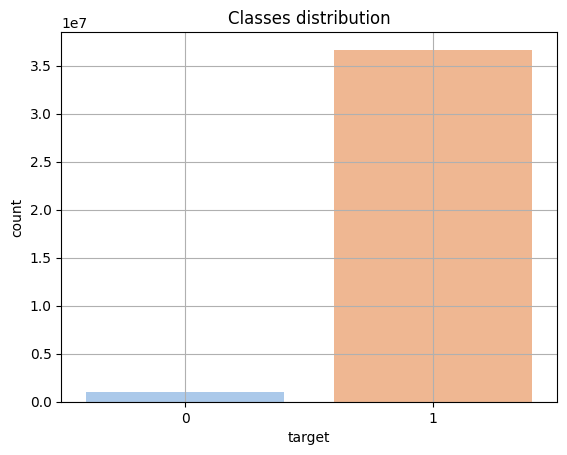

In [12]:
sns.countplot(data=df, x="target", palette="pastel")
plt.title("Classes distribution")
plt.grid(True)
plt.show()

### Temporal distribution

Accidents by hour

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\2785184215.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


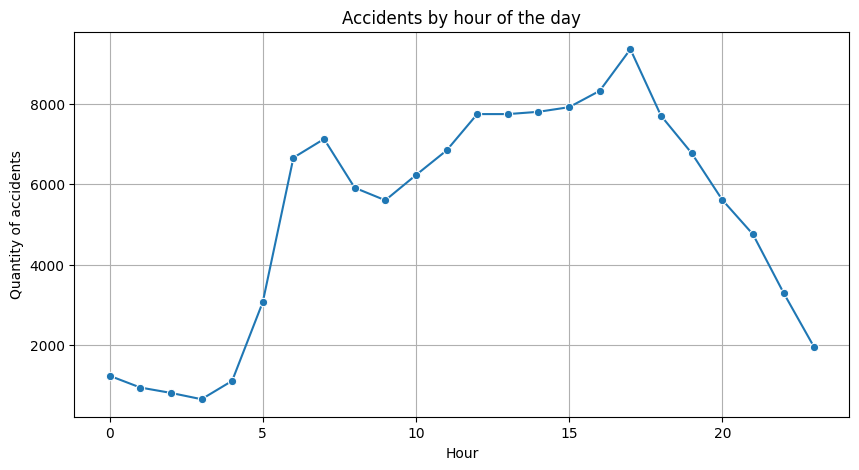

In [13]:
accidents_by_hour = (
    raw.groupby("Hora_num")
       .size()
       .reset_index(name="quantity")
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=accidents_by_hour,
    x="Hora_num",
    y="quantity",
    marker="o",
    palette="pastel"
)

plt.title("Accidents by hour of the day")
plt.xlabel("Hour")
plt.ylabel("Quantity of accidents")
plt.grid(True)

plt.show()

Accidents by day

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\17242679.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


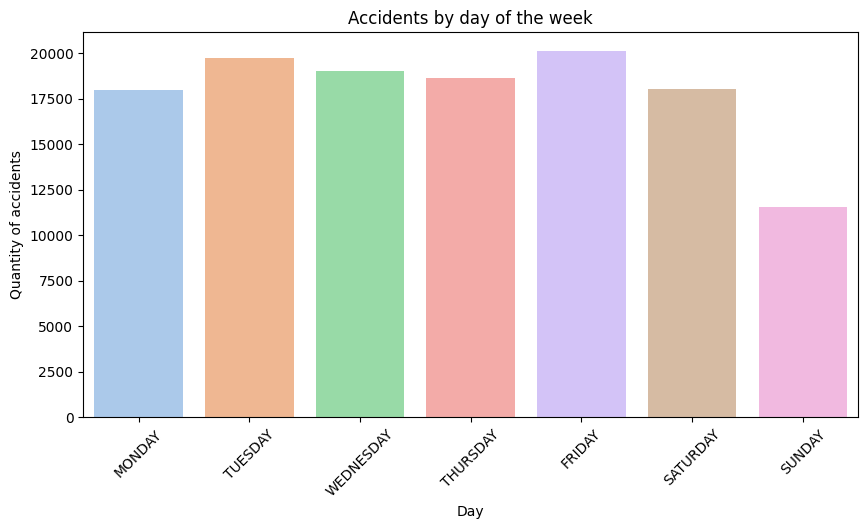

In [14]:
days_order = {
    "LUNES": "MONDAY",
    "MARTES": "TUESDAY",
    "MIERCOLES": "WEDNESDAY",
    "JUEVES": "THURSDAY",
    "VIERNES": "FRIDAY",
    "SABADO": "SATURDAY",
    "DOMINGO": "SUNDAY"
}

day_accidents = (
    raw["Dia_sem"]
    .value_counts()
    .reindex(days_order.keys())
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=list(days_order.values()),
    y=day_accidents.values,
    palette="pastel"
)

plt.title("Accidents by day of the week")
plt.xticks(rotation=45)
plt.ylabel("Quantity of accidents")
plt.xlabel("Day")

plt.show()

Accidents by month

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\2365164407.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


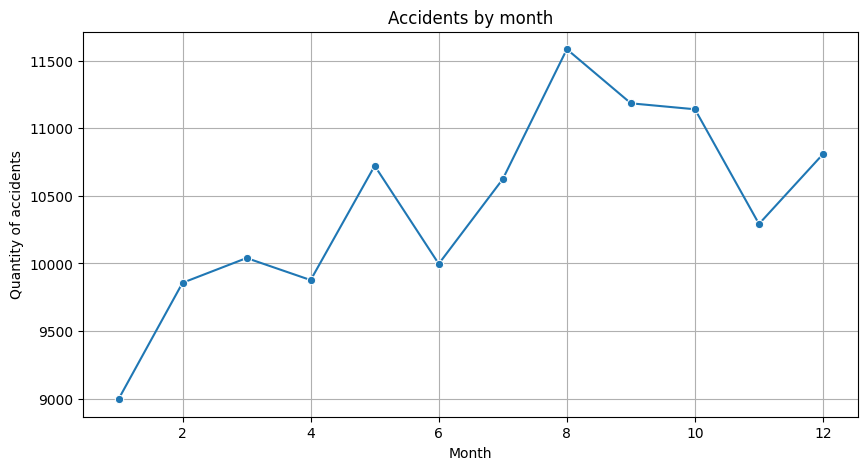

In [15]:
month_accidents = (
    raw.groupby("Mes")
       .size()
       .reset_index(name="cantidad")
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=month_accidents,
    x="Mes",
    y="cantidad",
    marker="o",
    palette="pastel"
)

plt.title("Accidents by month")
plt.xlabel("Month")
plt.ylabel("Quantity of accidents")
plt.grid(True)
plt.show()

### Spacial distribution

Neighborhood with the most accidents

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\3202720401.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


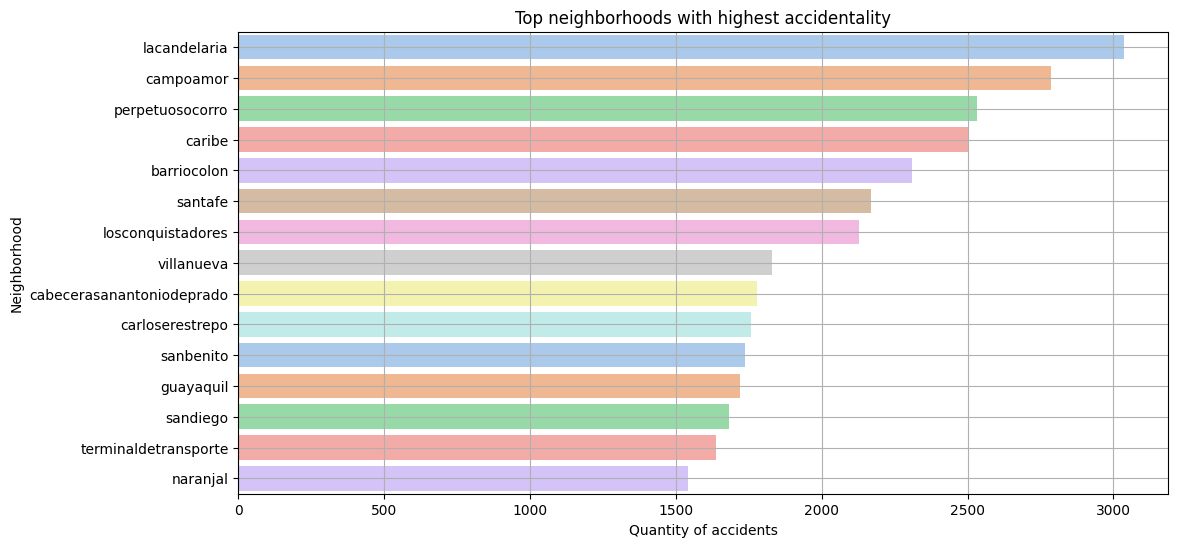

In [16]:
top_neighborhoods = (
    raw["BARRIO"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_neighborhoods.values,
    y=top_neighborhoods.index,
    palette="pastel"
)

plt.title("Top neighborhoods with highest accidentality")
plt.xlabel("Quantity of accidents")
plt.ylabel("Neighborhood")
plt.grid(True)
plt.show()

Top districts

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\4228345226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


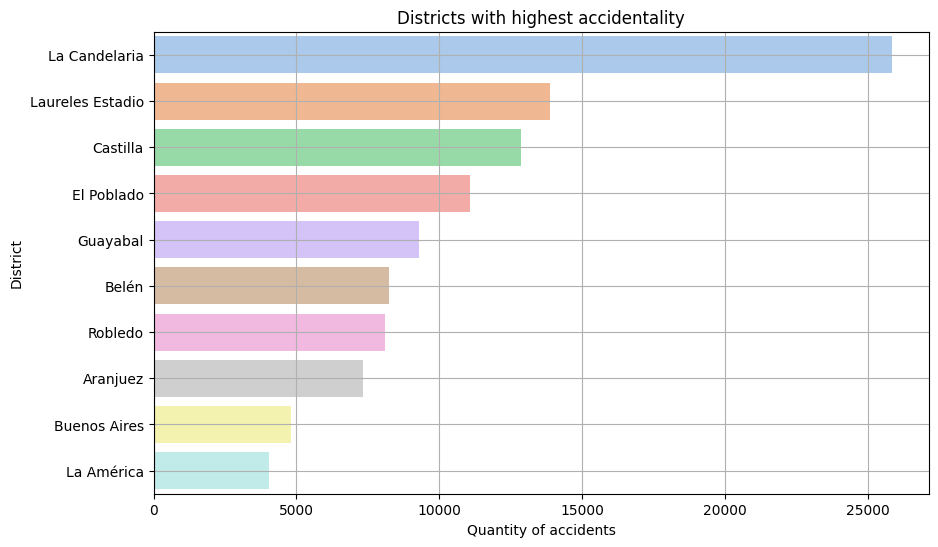

In [17]:
top_districts = raw["COMUNA"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_districts.values,
    y=top_districts.index,
    palette="pastel"
)

plt.title("Districts with highest accidentality")
plt.xlabel("Quantity of accidents")
plt.ylabel("District")
plt.grid(True)
plt.show()

## Weather and accidentality

In [18]:
weather_variables = [
    "temperature",
    "humidity",
    "windSpeed",
    "precipProbability"
]

df[weather_variables].describe()

,temperature,humidity,windSpeed,precipProbability
count,3.769041e+07,3.769011e+07,3.760805e+07,3.521685e+07
mean,2.085365e+01,6.990460e-01,1.875685e+00,1.481325e-01
std,3.776583e+00,1.646232e-01,1.356441e+00,1.997768e-01
min,4.510000e+00,1.700000e-01,0.000000e+00,0.000000e+00
25%,1.777000e+01,5.800000e-01,1.010000e+00,0.000000e+00
50%,2.056000e+01,7.100000e-01,1.600000e+00,6.000000e-02
75%,2.388000e+01,8.200000e-01,2.520000e+00,2.500000e-01
max,3.599000e+01,1.000000e+00,1.526000e+01,1.000000e+00


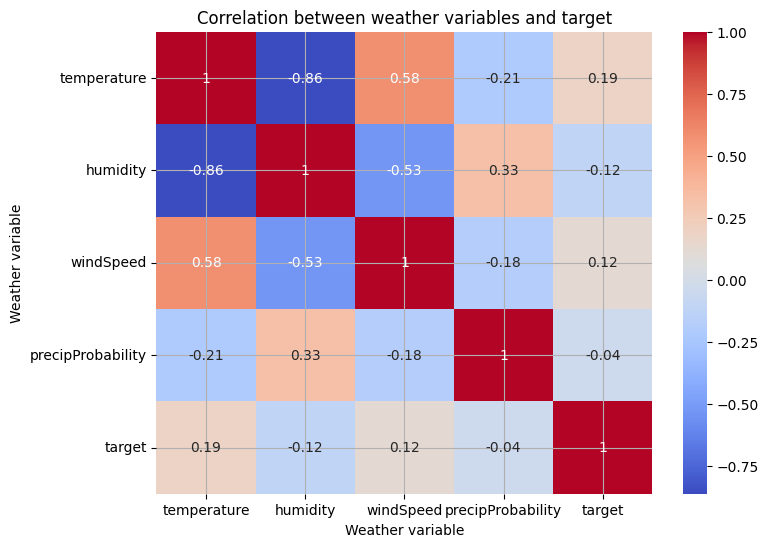

In [19]:
corr = df[
    weather_variables + ["target"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation between weather variables and target")
plt.xlabel("Weather variable")
plt.ylabel("Weather variable")
plt.grid(True)

plt.show()

C:\Users\Luisa\AppData\Local\Temp\ipykernel_35644\2722002008.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


KeyboardInterrupt: 

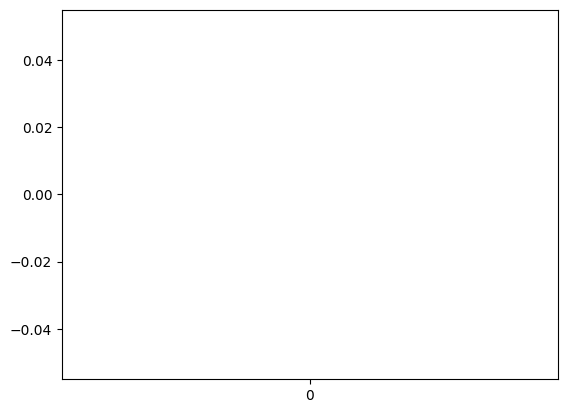

In [20]:
sns.boxplot(
    data=df,
    x="target",
    y="precipProbability",
    palette="pastel"
)

plt.title("Probability of rain vs accidentality")
plt.xlabel("Accidentality")
plt.ylabel("Probability of rain")
plt.grid(True)

plt.show()